### Testing Batch Normalization
We are going to discover how using Batch normalization affects neural network.

MNIST datset is used as target dataset

### We use 4 diffrent models:
- without batch normalization
- one layer of batch normalization
- two layers of batch normalization
- three layers of batch normalization (all 3)

#### We evaluate the results based on 
- Trainning time
- Testing accuracy
- Testing loss

#### The fixed configurations are:
- 3 Hidden layers
- RMSProp optimizer
- 32 batch size
- 3 epoch
- 0.001 learning rate
- He initialization for hidden layers and Xavier for output layer


In [1]:
#Change directory for importing 

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
#Load and preprocess MNIST dataset from keras
from load_mnist import load_handwritten_digits

X_train, y_train, X_test, y_test = load_handwritten_digits()

In [3]:
import time #For calculating training time

results = dict() #{n_layers: (accuracy, loss, time)}

In [7]:
from deep_neural_network.core.main_structure import NeuralNetwork

btchsize = 32 # Best approved batch size
rs = 455 # Random state
lr = 0.001 # Learning rate
optim = "RMSProp" # Optimizer
hidden_init = "He"

In [11]:
for n_batch_norm in range(0,4):
    print(f"------------- {n_batch_norm} batch normalizations ----------------")

    # Initialize the network
    net = NeuralNetwork(n_features = 784,
                        task = "MultiClassifier",
                        learning_rate = lr,
                        random_state =rs)
    
    # Add hidden layers with batch norm condition
    
    hidden_sizes = [64, 32, 16]
    for i, size in enumerate(hidden_sizes):
        use_batchnorm = i < n_batch_norm
    
        net.add_layer(
            size,
            "ReLU",
            hidden_init,
            use_batchnorm
        )

    # Add output layer
    net.add_layer(
        10,
        "Softmax",
        "Xavier",
        False
    )

    # Set the fixed optimizer
    net.set_optimizer(optim)

    # Start training
    start = time.perf_counter()
    net.fit(X = X_train,
           y = y_train,
           epoch = 3,
           batch_size = btchsize,
           monitor_every_n = 3)

    elapsed = time.perf_counter() - start #Timer stops!
    accuracy, loss = net.evaluate(X_test, y_test)
    
    # Save the results
    results[n_batch_norm] = (accuracy, loss, elapsed)

    print(f"{n_batch_norm}, time: {elapsed}")
    print(f"{n_batch_norm}, accuracy: {accuracy}")
    print(f"{n_batch_norm}, loss: {loss}")

------------- 0 batch normalizations ----------------
epoch: 3, loss: 0.08224807910299044
0, time: 22.040187600068748
0, accuracy: 0.9655
0, loss: 0.11595296664861666
------------- 1 batch normalizations ----------------
epoch: 3, loss: 0.0608595876030728
1, time: 25.144430199987255
1, accuracy: 0.9701
1, loss: 0.09391255495397673
------------- 2 batch normalizations ----------------
epoch: 3, loss: 0.05665824372037809
2, time: 26.42765349999536
2, accuracy: 0.973
2, loss: 0.08636456543932326
------------- 3 batch normalizations ----------------
epoch: 3, loss: 0.06546932370015039
3, time: 29.104119100025855
3, accuracy: 0.9722
3, loss: 0.09130757729422877


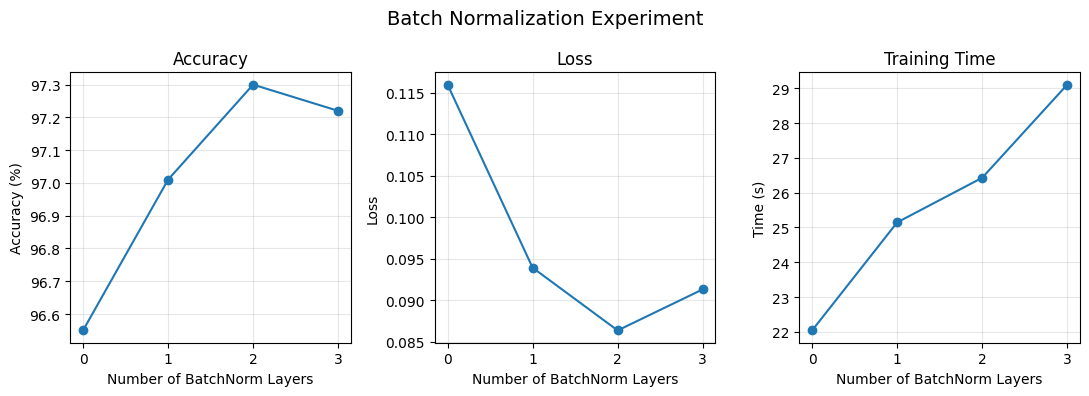

In [12]:
import matplotlib.pyplot as plt

n_layers = list(results.keys())

accuracies = [v[0] * 100 for v in results.values()]
losses = [v[1] for v in results.values()]
times = [v[2] for v in results.values()]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

# Accuracy
axes[0].plot(n_layers, accuracies, "o-")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Number of BatchNorm Layers")
axes[0].set_ylabel("Accuracy (%)")
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(n_layers, losses, "o-")
axes[1].set_title("Loss")
axes[1].set_xlabel("Number of BatchNorm Layers")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)

# Training time
axes[2].plot(n_layers, times, "o-")
axes[2].set_title("Training Time")
axes[2].set_xlabel("Number of BatchNorm Layers")
axes[2].set_ylabel("Time (s)")
axes[2].grid(alpha=0.3)

fig.suptitle("Batch Normalization Experiment", fontsize=14)

plt.tight_layout()

plt.savefig("test_results\\batchnorm_test.png")
plt.show()

### Conclusion

Results show that just having more batch normalization layers doesn't contribute to better results.
Curves indicate that the network with two batchnorm layers outperformed other ones (even the one with 3 layers!)
The training time trend is also logical and shows that neural networks with more batch normalization, take more 
time to train.

We can conclude that having 2 batch normalization layers (on this configurations and speciefic problem)
achieves better results with reasonable training time.